In [1]:
import pandas as pd

df = pd.read_csv('data/2019년화재.csv', encoding='cp949')
df.head()

,연번,사망,부상,인명피해(명)소계,재산피해소계,화재발생년월일,시도,시군구,읍면동,화재유형,발화열원,발화열원소분류,발화요인대분류,발화요인소분류,최초착화물대분류,최초착화물소분류,장소대분류,장소중분류,장소소분류
0,1,0,1,1,0,2019-01-01 0:03,강원도,삼척시,오분동,기타(쓰레기 화재등),"폭발물, 폭죽",폭죽,부주의,폭죽놀이,"종이,목재,건초등","풀, 나뭇잎",기타,야외,기타야외
1,2,0,0,0,14900,2019-01-01 0:06,경기도,평택시,안중읍,"건축,구조물",미상,미상,미상,미상,미상,미상,주거,단독주택,단독주택
2,3,0,0,0,3642,2019-01-01 0:40,서울특별시,성북구,하월곡동,"자동차,철도차량",미상,미상,미상,미상,미상,미상,"자동차,철도차량",자동차,승용자동차
3,4,0,0,0,1848,2019-01-01 0:52,경기도,이천시,설성면,기타(쓰레기 화재등),화학적 발화열,화학반응열,화학적 요인,자연발화,"종이,목재,건초등","풀, 나뭇잎",기타,야외,야적장
4,5,0,0,0,45,2019-01-01 1:06,부산광역시,부산진구,당감동,"건축,구조물",작동기기,기타(작동기기),전기적 요인,절연열화에 의한 단락,"전기,전자","전기, 전자기기 기판",기타서비스,기타건축물,기타 건축물


In [2]:
df_seoul = pd.read_excel('data/seoul.xlsx', sheet_name='Sheet1')
df_seoul.head(3)

,Unnamed: 0,1인세대비율,2인세대비율,3~4인세대비율,5인세대이상비율
0,성동구,0.444997,0.229265,0.293386,0.153171
1,관악구,0.627157,0.179437,0.172876,0.090143
2,도봉구,0.374269,0.263852,0.324080,0.170940


In [3]:
df_seoul = pd.read_excel('data/seoul.xlsx', sheet_name='Sheet1', index_col=0)
df_seoul.iloc[0:2,0:2]  #0행, 0열
print(df_seoul.loc['성동구', ['1인세대비율','2인세대비율']])

1인세대비율    0.444997
2인세대비율    0.229265
Name: 성동구, dtype: float64


In [4]:
filtered_df = df_seoul[df_seoul['1인세대비율'] >= 0.5]
filtered_df

,1인세대비율,2인세대비율,3~4인세대비율,5인세대이상비율
관악구,0.627157,0.179437,0.172876,0.090143
금천구,0.525809,0.221986,0.225772,0.115543
종로구,0.525979,0.200624,0.239987,0.132935
동대문구,0.501839,0.209695,0.257290,0.138268
광진구,0.502735,0.208159,0.260142,0.140188
중구,0.536372,0.218403,0.217850,0.111804
영등포구,0.504536,0.209959,0.256477,0.136300


In [5]:
# select * from df_seoul where 1인세대비율 >= 0.5 and 2인세대비율 < 0.2
# and: &, or: |, not: ~ (틸드)
cond1 = df_seoul['1인세대비율'] >= 0.5
cond2 = df_seoul['2인세대비율'] < 0.2
filtered_df = df_seoul[cond1 & cond2]
filtered_df

,1인세대비율,2인세대비율,3~4인세대비율,5인세대이상비율
관악구,0.627157,0.179437,0.172876,0.090143


In [6]:
df = pd.read_csv('data/2019년화재.csv', encoding='CP949') # CP949 >> ANSI
df.tail(1)

,연번,사망,부상,인명피해(명)소계,재산피해소계,화재발생년월일,시도,시군구,읍면동,화재유형,발화열원,발화열원소분류,발화요인대분류,발화요인소분류,최초착화물대분류,최초착화물소분류,장소대분류,장소중분류,장소소분류
40102,40103,0,0,0,3879,2019-12-31 23:18,인천광역시,남동구,고잔동,"건축,구조물",작동기기,전기적 아크(단락),전기적 요인,"압착,손상에 의한 단락","전기,전자",전선피복,산업시설,공장시설,"전기, 전자공업"


In [7]:
# 새 열 추가
# SELECT 사망 + 부상 AS 인명피해
df['인명피해'] = df['사망'] + df['부상']
df['인명피해'] # 시리즈 출력

0        1
1        0
2        0
3        0
4        0
        ..
40098    0
40099    0
40100    0
40101    0
40102    0
Name: 인명피해, Length: 40103, dtype: int64

In [8]:
# select age - 1 as age
# 기존 열을 수정
df['연번'] = df['연번'] - 1
df.head(5)

,연번,사망,부상,인명피해(명)소계,재산피해소계,화재발생년월일,시도,시군구,읍면동,화재유형,발화열원,발화열원소분류,발화요인대분류,발화요인소분류,최초착화물대분류,최초착화물소분류,장소대분류,장소중분류,장소소분류,인명피해
0,0,0,1,1,0,2019-01-01 0:03,강원도,삼척시,오분동,기타(쓰레기 화재등),"폭발물, 폭죽",폭죽,부주의,폭죽놀이,"종이,목재,건초등","풀, 나뭇잎",기타,야외,기타야외,1
1,1,0,0,0,14900,2019-01-01 0:06,경기도,평택시,안중읍,"건축,구조물",미상,미상,미상,미상,미상,미상,주거,단독주택,단독주택,0
2,2,0,0,0,3642,2019-01-01 0:40,서울특별시,성북구,하월곡동,"자동차,철도차량",미상,미상,미상,미상,미상,미상,"자동차,철도차량",자동차,승용자동차,0
3,3,0,0,0,1848,2019-01-01 0:52,경기도,이천시,설성면,기타(쓰레기 화재등),화학적 발화열,화학반응열,화학적 요인,자연발화,"종이,목재,건초등","풀, 나뭇잎",기타,야외,야적장,0
4,4,0,0,0,45,2019-01-01 1:06,부산광역시,부산진구,당감동,"건축,구조물",작동기기,기타(작동기기),전기적 요인,절연열화에 의한 단락,"전기,전자","전기, 전자기기 기판",기타서비스,기타건축물,기타 건축물,0


In [9]:
# lambda(람다) 식
# 한 줄로 쓰는 함수

def get_square(n):
    return n ** 2

print(get_square(3))

lambda_square = lambda x: x ** 2

print(lambda_square(3))

9
9


In [10]:
# SELECT
# CASE
#   WHEN 재산피해 <= 1000 THEN '소형화재'
#   ELSE '대형화재'
# END
df['화재크기분류'] = df['재산피해소계'].apply(lambda x: '소형' if x <= 1000 else '대형')
df.head(2)

,연번,사망,부상,인명피해(명)소계,재산피해소계,화재발생년월일,시도,시군구,읍면동,화재유형,...,발화열원소분류,발화요인대분류,발화요인소분류,최초착화물대분류,최초착화물소분류,장소대분류,장소중분류,장소소분류,인명피해,화재크기분류
0,0,0,1,1,0,2019-01-01 0:03,강원도,삼척시,오분동,기타(쓰레기 화재등),...,폭죽,부주의,폭죽놀이,"종이,목재,건초등","풀, 나뭇잎",기타,야외,기타야외,1,소형
1,1,0,0,0,14900,2019-01-01 0:06,경기도,평택시,안중읍,"건축,구조물",...,미상,미상,미상,미상,미상,주거,단독주택,단독주택,0,대형


In [11]:
# 데이터 프래임의 한 행씩 이 함수를 호출
def classify_fire(row):
    if row['재산피해소계'] < 500:
        return '소형'
    elif row['재산피해소계']<10000:
        return '중형'
    else:
        return '대형'
    
df['화재크기분류'] = df.apply(classify_fire, axis=1)
df.head(4)

# 중형화재 데이터를 필터하여 출력
# 1. 재산피해액으로 필터, 2. 중형화재로 필터
cond1 = df['재산피해소계'] >= 5000
cond2 = df['화재크기분류'] == '중형'
filtered_df = df[cond1 & cond2]

cond1 = df['재산피해소계'] >= 500
cond2 = df['재산피해소계'] < 10000
filtered_df = df[cond1 & cond2]
filtered_df['화재크기분류'].value_counts()

# python에서 pandas로 만든 데이터프레임에는 화재크기분류

화재크기분류
중형    15890
Name: count, dtype: int64

In [12]:
# 열 삭제
# 1: 열
# 0: 행
new_df = df.drop('연번', axis=1)
new_df.head(2)

df.drop(0,axis=0) # 행 삭제시 인덱스 지정

,연번,사망,부상,인명피해(명)소계,재산피해소계,화재발생년월일,시도,시군구,읍면동,화재유형,...,발화열원소분류,발화요인대분류,발화요인소분류,최초착화물대분류,최초착화물소분류,장소대분류,장소중분류,장소소분류,인명피해,화재크기분류
1,1,0,0,0,14900,2019-01-01 0:06,경기도,평택시,안중읍,"건축,구조물",...,미상,미상,미상,미상,미상,주거,단독주택,단독주택,0,대형
2,2,0,0,0,3642,2019-01-01 0:40,서울특별시,성북구,하월곡동,"자동차,철도차량",...,미상,미상,미상,미상,미상,"자동차,철도차량",자동차,승용자동차,0,중형
3,3,0,0,0,1848,2019-01-01 0:52,경기도,이천시,설성면,기타(쓰레기 화재등),...,화학반응열,화학적 요인,자연발화,"종이,목재,건초등","풀, 나뭇잎",기타,야외,야적장,0,중형
4,4,0,0,0,45,2019-01-01 1:06,부산광역시,부산진구,당감동,"건축,구조물",...,기타(작동기기),전기적 요인,절연열화에 의한 단락,"전기,전자","전기, 전자기기 기판",기타서비스,기타건축물,기타 건축물,0,소형
5,5,0,0,0,50,2019-01-01 1:14,서울특별시,서초구,우면동,"건축,구조물",...,"기기 전도,복사열",부주의,음식물 조리중,식품,음식물,주거,공동주택,아파트,0,소형
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40098,40098,0,0,0,23707,2019-12-31 22:33,경기도,파주시,광탄면,"건축,구조물",...,전기적 아크(단락),전기적 요인,접촉불량에 의한 단락,"전기,전자",전선피복,산업시설,공장시설,제재 및 목공업,0,대형
40099,40099,0,0,0,3542,2019-12-31 22:45,경상북도,경산시,남방동,"건축,구조물",...,미상,미상,미상,"종이,목재,건초등",건초,산업시설,동식물시설,기타 동식물시설,0,중형
40100,40100,0,0,0,0,2019-12-31 22:47,부산광역시,남구,문현동,"건축,구조물",...,"기기 전도,복사열",부주의,음식물 조리중,식품,튀김유,"판매,업무시설",일반업무,오피스텔,0,소형
40101,40101,0,0,0,105,2019-12-31 23:05,제주특별자치도,제주시,외도일동,"건축,구조물",...,"기기 전도,복사열",부주의,가연물 근접방치,합성수지,"플라스틱, PVC, 비닐, 장판","판매,업무시설",판매시설,할인점(마트),0,소형


In [13]:
# 새로운 데이터프레임을 반환하지 않고 열 삭제
# inplace=True
df.drop('연번', axis=1, inplace=True)
df.head(4)

,사망,부상,인명피해(명)소계,재산피해소계,화재발생년월일,시도,시군구,읍면동,화재유형,발화열원,발화열원소분류,발화요인대분류,발화요인소분류,최초착화물대분류,최초착화물소분류,장소대분류,장소중분류,장소소분류,인명피해,화재크기분류
0,0,1,1,0,2019-01-01 0:03,강원도,삼척시,오분동,기타(쓰레기 화재등),"폭발물, 폭죽",폭죽,부주의,폭죽놀이,"종이,목재,건초등","풀, 나뭇잎",기타,야외,기타야외,1,소형
1,0,0,0,14900,2019-01-01 0:06,경기도,평택시,안중읍,"건축,구조물",미상,미상,미상,미상,미상,미상,주거,단독주택,단독주택,0,대형
2,0,0,0,3642,2019-01-01 0:40,서울특별시,성북구,하월곡동,"자동차,철도차량",미상,미상,미상,미상,미상,미상,"자동차,철도차량",자동차,승용자동차,0,중형
3,0,0,0,1848,2019-01-01 0:52,경기도,이천시,설성면,기타(쓰레기 화재등),화학적 발화열,화학반응열,화학적 요인,자연발화,"종이,목재,건초등","풀, 나뭇잎",기타,야외,야적장,0,중형


In [14]:
df_titanic = pd.read_csv('data/titanic.csv')
df_titanic.isna().head(3)
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [15]:
# 고정값으로 결측치 대체
df_titanic['Cabin'] = df_titanic['Cabin'].fillna('C000')
# 평균값으로 결측치 대체
df_titanic['Age'] = df_titanic['Age'].fillna(df_titanic['Age'].mean())

In [16]:
# 중복 제거
data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'Alice', 'Bob'],
    'Age': [25, 30, 35, 25, 30],
    'City': ['New York', 'Los Angeles', 'Chicago', 'New York', 'Los Angeles']
}
df_dup = pd.DataFrame(data)
print(df_dup)
df_dup.duplicated()

no_dup = df_dup.drop_duplicates()
no_dup

      Name  Age         City
0    Alice   25     New York
1      Bob   30  Los Angeles
2  Charlie   35      Chicago
3    Alice   25     New York
4      Bob   30  Los Angeles


,Name,Age,City
0,Alice,25,New York
1,Bob,30,Los Angeles
2,Charlie,35,Chicago


In [17]:
# select sum(재산피해소계) from 테이블
df['재산피해소계'].sum()

np.int64(858496234)

In [18]:
# select sum(재산피해소계) from 테이블 where 시도 = '경기도'
df[df['시도']=='경기도']['재산피해소계'].sum()

np.int64(209842482)

In [19]:
# select 시도, sum(재산피해소계) from 테이블 group by 시도
df.groupby('시도')['재산피해소계'].sum()

# select 시도, sum(재산피해소계) from 테이블 group by 시도, 시군구
df.groupby(['시도','시군구'])['재산피해소계'].sum()

시도    시군구   
강원도   강릉시       109898759
      고성군       118686425
      동해시          406116
      삼척시          570107
      속초시          389518
                  ...    
충청북도  청주시상당구       527335
      청주시서원구      7539555
      청주시청원구      5171479
      청주시흥덕구      2326269
      충주시         8207768
Name: 재산피해소계, Length: 250, dtype: int64

In [20]:
# 2018, 2019년의 화재 데이터를 각각 로드
df_2018 = pd.read_csv('data/2018년화재.csv',encoding='cp949')
df_2019 = pd.read_csv('data/2019년화재.csv',encoding='cp949')

print('2018 shape: {}'.format(df_2018.shape))
print('2019 shape: {}'.format(df_2019.shape))

2018 shape: (42338, 19)
2019 shape: (40103, 19)


In [21]:
df_total = pd.concat([df_2018, df_2019])
df_total

,연번,사망,부상,인명피해(명)소계,재산피해소계,화재발생년월일,시도,시군구,읍면동,화재유형,발화열원,발화열원소분류,발화요인대분류,발화요인소분류,최초착화물대분류,최초착화물소분류,장소대분류,장소중분류,장소소분류
0,1,0,1,1,24099,2018-01-01 00:03,경기도,고양시일산동구,사리현동,"건축,구조물",작동기기,전기적 아크(단락),전기적 요인,미확인단락,"전기,전자",전선피복,주거,단독주택,상가주택(주택부분에서 화재가 발생한 경우에만 해당)
1,2,0,0,0,2758,2018-01-01 00:12,전라북도,완주군,상관면,"건축,구조물","마찰, 전도, 복사","화염 전도,복사열",부주의,가연물 근접방치,"종이,목재,건초등",종이,주거,단독주택,단독주택
2,3,0,0,0,28,2018-01-01 00:16,경기도,남양주시,화도읍,임야,"담뱃불, 라이터불",담뱃불,부주의,담배꽁초,"종이,목재,건초등",건초,임야,산불,공유림
3,4,0,0,0,1942,2018-01-01 00:28,충청남도,보령시,화산동,"건축,구조물",작동기기,"기기 전도,복사열",기계적 요인,"과열, 과부하",합성수지,"플라스틱, PVC, 비닐, 장판",주거,단독주택,단독주택
4,5,0,0,0,1401,2018-01-01 00:38,전라남도,순천시,서면,"건축,구조물","불꽃, 불티",굴뚝(연통) 아궁이,부주의,가연물 근접방치,"종이,목재,건초등","목재, 합판",주거,단독주택,단독주택
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40098,40099,0,0,0,23707,2019-12-31 22:33,경기도,파주시,광탄면,"건축,구조물",작동기기,전기적 아크(단락),전기적 요인,접촉불량에 의한 단락,"전기,전자",전선피복,산업시설,공장시설,제재 및 목공업
40099,40100,0,0,0,3542,2019-12-31 22:45,경상북도,경산시,남방동,"건축,구조물",미상,미상,미상,미상,"종이,목재,건초등",건초,산업시설,동식물시설,기타 동식물시설
40100,40101,0,0,0,0,2019-12-31 22:47,부산광역시,남구,문현동,"건축,구조물",작동기기,"기기 전도,복사열",부주의,음식물 조리중,식품,튀김유,"판매,업무시설",일반업무,오피스텔
40101,40102,0,0,0,105,2019-12-31 23:05,제주특별자치도,제주시,외도일동,"건축,구조물",작동기기,"기기 전도,복사열",부주의,가연물 근접방치,합성수지,"플라스틱, PVC, 비닐, 장판","판매,업무시설",판매시설,할인점(마트)


In [23]:
# 연도별 재산피해소계의 합을 구한다.
df_total['화재발생년월일'] = pd.to_datetime(df_total['화재발생년월일'])
df_total.groupby(df_total['화재발생년월일'].dt.year)['재산피해소계'].sum()


화재발생년월일
2018    559712389
2019    858496234
Name: 재산피해소계, dtype: int64

In [24]:
df_sales = pd.read_excel('data/adw.xlsx',sheet_name='인터넷판매')
df_customer = pd.read_excel('data/adw.xlsx',sheet_name='고객')

print('df_sales: {}'.format(df_sales.shape))
print('df_customer: {}'.format(df_customer.shape))

c:\Users\samsung\anaconda3\envs\projectA\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


df_sales: (60398, 26)
df_customer: (18484, 25)


c:\Users\samsung\anaconda3\envs\projectA\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


In [25]:
# select *
# from 인터넷판매 i
#   join 고객 c on c.고객키 = i.고객키
df_adw = pd.merge(df_sales, df_customer, on='고객키', how='inner')
df_adw.shape

(60398, 50)

In [26]:
%pip install matplotlib

     ---------------------------------------- 0.0/167.0 kB ? eta -:--:--
     -------------------------------------- 167.0/167.0 kB 5.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
   ------- -------------------------------- 1.4/7.8 MB 29.4 MB/s eta 0:00:01
   -------------- ------------------------- 2.8/7.8 MB 29.2 MB/s eta 0:00:01
   ------------------------ --------------- 4.8/7.8 MB 34.1 MB/s eta 0:00:01
   ---------------------------------- ----- 6.8/7.8 MB 36.3 MB/s eta 0:00:01
   ---------------------------------------- 7.8/7.8 MB 33.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/218.3 kB ? eta -:--:--
   ---------------------------------------- 218.3/218.3 kB ? eta 0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ------------------ --------------------- 1.0/2.2 MB 32.3 MB/s eta 0:00:01
   --------------------------------- ------ 1.8/2.2 MB 19.5 MB/s eta 0:00:01
   -----------------------

<Axes: xlabel='성별'>

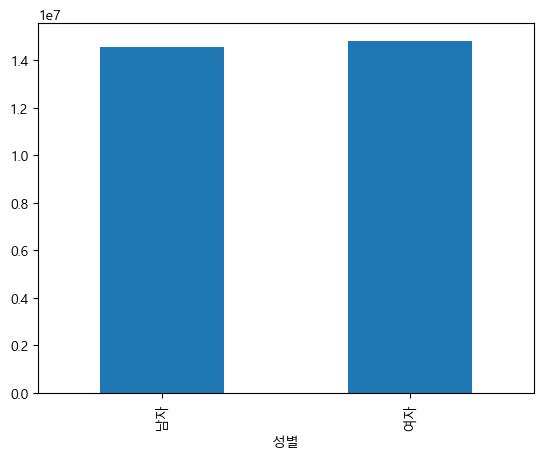

In [28]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'

result = df_adw.groupby('성별')['판매금액'].sum()
result.plot(kind='bar')

<Axes: ylabel='Frequency'>

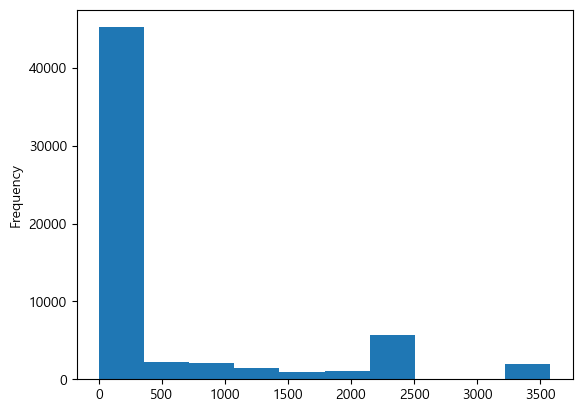

In [29]:
df_adw['판매금액'].plot(kind='hist')